# Plot Multispectral Imagery

In [1]:
import os
import sys
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio.plot
from exactextract import exact_extract
from rasterio.merge import merge
from tqdm import tqdm

sys.path.append("../utils")

import config


#### Import single PlanetScope scene for plotting

Date: May 19, 2025

In [3]:
path = "/capstone/wildfire_prep/leilanie/data-preparation/data/2025-05-19-PS-for-presentation_psscene_analytic_sr_udm2/composite.tif"

In [4]:
def import_training_geometries(year):
        """
        Function to read in buffer geometry data for a given year and convert to Albers CRS.
        """
        training_geometries = os.path.join(
            config.data_dir,
            "training_geometries",
            f"training_geometries_{year}.geojson",
        )
        return gpd.read_file(training_geometries).to_crs(config.albers_crs)
    
# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_training_geometries(year)
    
# Unpack from dictionary
geometries_2019 = inspections_dict[2019]
geometries_2020 = inspections_dict[2020]
geometries_2021 = inspections_dict[2021]
geometries_2022 = inspections_dict[2022]
geometries_2023 = inspections_dict[2023]    

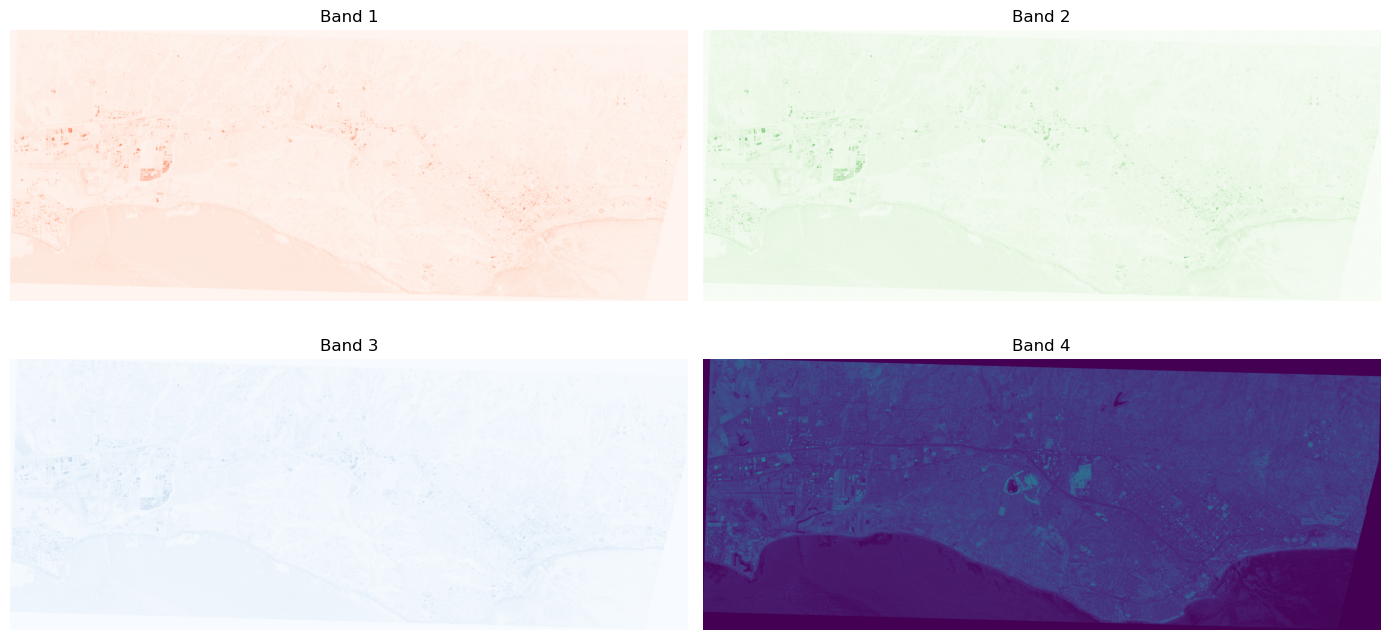

Metadata:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 6808, 'height': 2724, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]'), 'transform': Affine(3.0, 0.0, 237090.0,
       0.0, -3.0, 3817311.0)}
Original data range:
Min: 0, Max: 25352
Stretched data range:
Band 1 - Min: 0.000, Max: 13961.000
Band 2 - Min: 0.000, Max: 13585.000
Band 3 - Min: 0.000, Max: 25352.000
Band 4 - Min: 0.000, Max: 160

In [5]:
# Open path with rasterio
with rasterio.open(path) as src:
    # Read the data
    data = src.read()
    # Get the metadata
    meta = src.meta
    
rgb_image = np.stack([data[2], data[1], data[0]], axis=-1)

# Plot all 4 bands with stretching applied
fig, axs = plt.subplots(2, 2, figsize=(14, 7))
axs = axs.flatten()

colormaps = ["Reds", "Greens", "Blues", "viridis"]
for i in range(4):
    axs[i].imshow(data[i], cmap=colormaps[i])
    axs[i].set_title(f"Band {i + 1}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

# Print the metadata and get the range of values
print("Metadata:")
print(meta)
print("Original data range:")
print(f"Min: {data.min()}, Max: {data.max()}")
print("Stretched data range:")
for i, band in enumerate(data):
    print(f"Band {i+1} - Min: {band.min():.3f}, Max: {band.max():.3f}")
print("Data shape:")
print(data.shape)

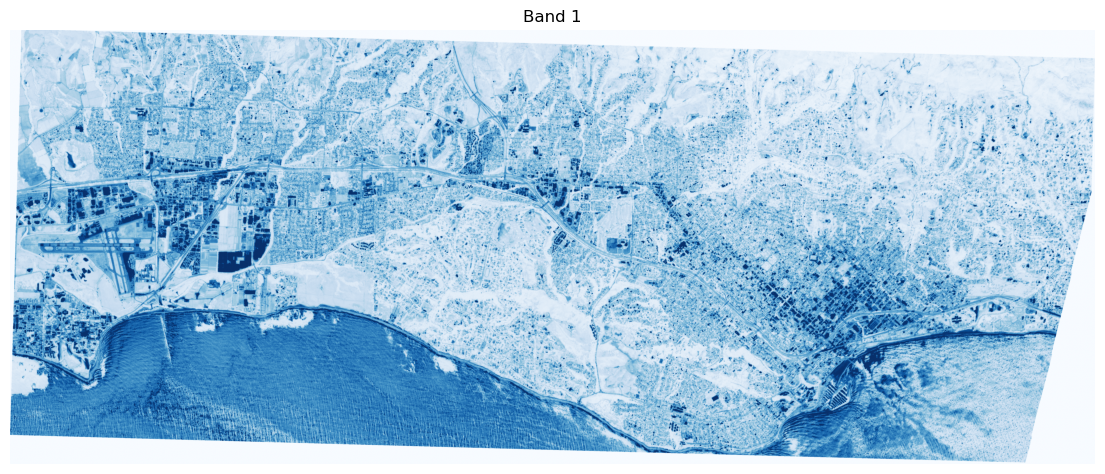

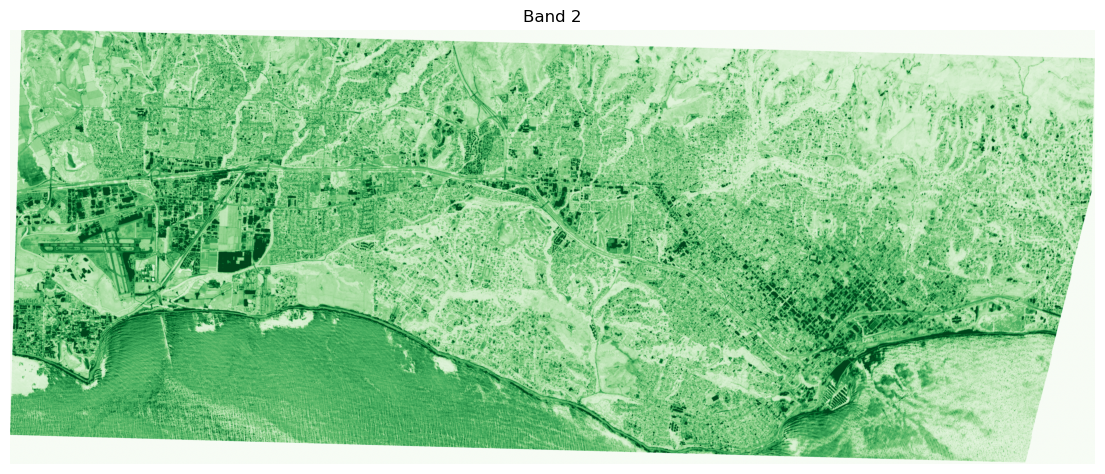

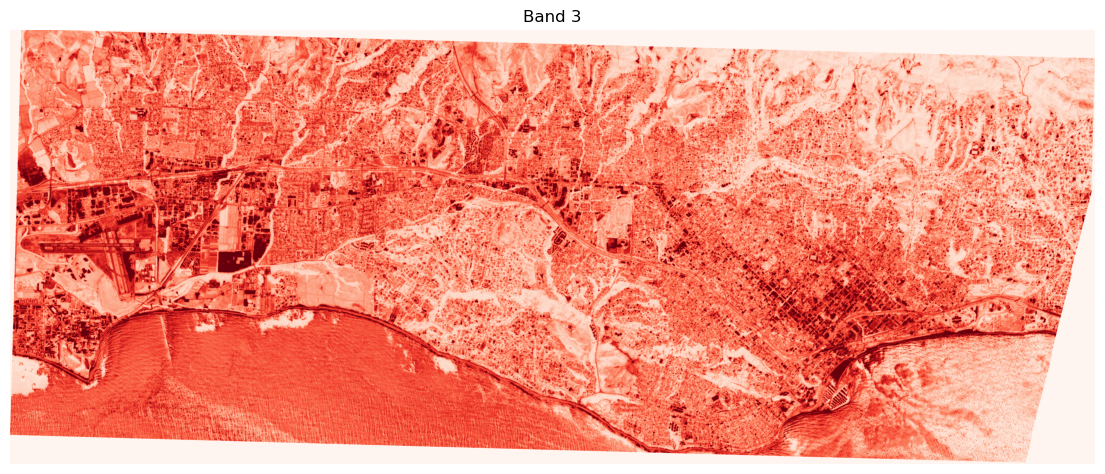

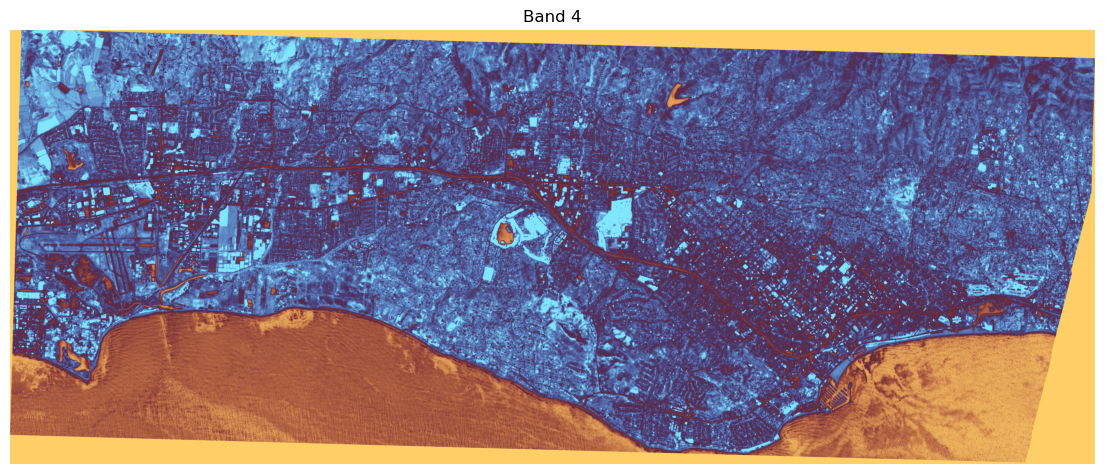

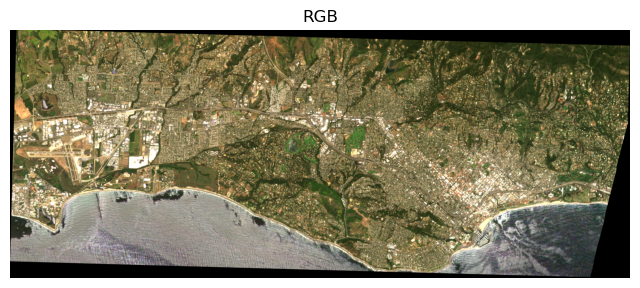

In [7]:
def percentile_stretch(band, lower_percentile=2, upper_percentile=98):
    """Apply percentile stretch to enhance contrast"""
    lower_val = np.percentile(band, lower_percentile)
    upper_val = np.percentile(band, upper_percentile)
    stretched = np.clip((band - lower_val) / (upper_val - lower_val), 0, 1)
    return stretched

# Apply percentile stretch
stretched_bands = []
for i in range(4):
    stretched_band = percentile_stretch(data[i])
    stretched_bands.append(stretched_band)
    
rgb_stretched = percentile_stretch(rgb_image)

# Plot each stretched band separately
colormaps = ["Blues", "Greens", "Reds", "managua"]
for i in range(4):
    plt.figure(figsize=(14, 8))
    plt.imshow(stretched_bands[i], cmap=colormaps[i])
    plt.title(f"Band {i + 1}")
    plt.axis("off")
    plt.show()

# Plot the stretched RGB composite separately
plt.figure(figsize=(8, 5))
plt.imshow(rgb_stretched)
plt.title("RGB")
plt.axis("off")
plt.show()

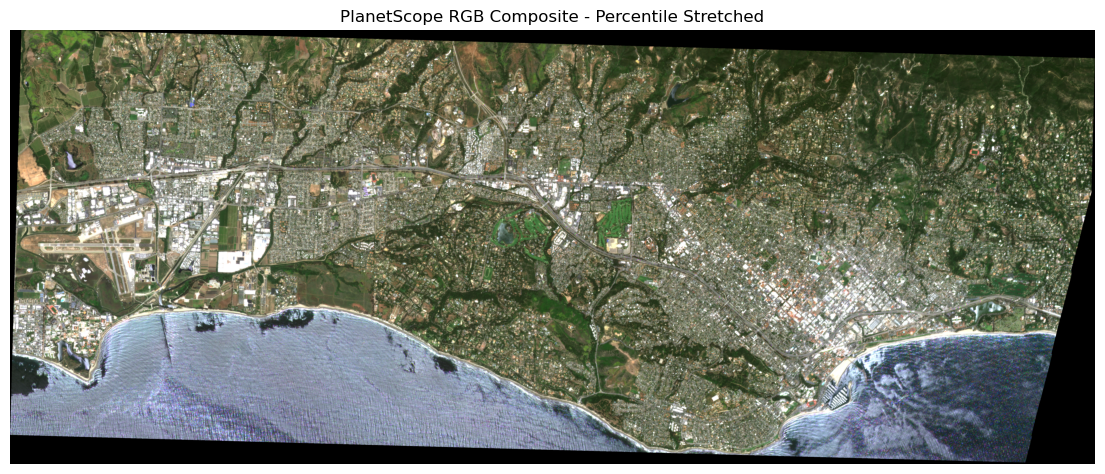

In [51]:
# Define colors for each band
red = data[2]
green = data[1]
blue = data[0]

# Use percentile stretch instead of min-max normalization
def percentile_stretch(band, lower_percentile=2, upper_percentile=98):
    """Apply percentile stretch to enhance contrast"""
    lower_val = np.percentile(band, lower_percentile)
    upper_val = np.percentile(band, upper_percentile)
    stretched = np.clip((band - lower_val) / (upper_val - lower_val), 0, 1)
    return stretched

red_stretched = percentile_stretch(red)
green_stretched = percentile_stretch(green)
blue_stretched = percentile_stretch(blue)

# Stack the stretched bands into an RGB array
rgb = np.stack([red_stretched, green_stretched, blue_stretched], axis=2)

# Display the RGB composite
plt.figure(figsize=(14, 7))
plt.imshow(rgb)
plt.title('PlanetScope RGB Composite - Percentile Stretched')
plt.axis('off')
plt.show()

In [40]:
geometries = gpd.read_file(
    os.path.join(config.data_dir, "PUZZLE_PIECES", "inspections_master_training_geometries.geojson")
)
geometries_2019 = geometries[geometries["year"] == 2019]
geometries_2019_04 = geometries_2019[geometries_2019["month"] == 4]

In [ ]:
# path = os.path.join(
#     "/data/wildfire_prep/full_planet/unzipped",
#     "2019",
#     "apr",
#     "files",
#     "20190401_173755_0f32_3B_AnalyticMS_SR_clip_bandmath.tif",
# )

In [9]:
meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 2835,
 'height': 2941,
 'count': 5,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'),
 'transform': Affine(3.0, 0.0, 741162.0,
        0.0, -3.0, 3825231.0)}

In [ ]:
with rasterio.open(path) as src:
    band_red = src.read(3)

with rasterio.open(path) as src:
    band_nir = src.read(4)
    
# Allow division by zero
np.seterr(divide='ignore', invalid='ignore')

# Calculate NDVI
ndvi = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)

# Plot NDVI
plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar()
plt.title("NDVI")
plt.show()

In [47]:
geometries_2019_04 = geometries_2019_04.to_crs(meta["crs"])

In [49]:
# First, calculate NDVI as you did
with rasterio.open(path) as src:
    band_red = src.read(3)
    band_nir = src.read(4)
    
    # Store the metadata for later use
    ndvi_meta = src.meta.copy()
    transform = src.transform

# Calculate NDVI
ndvi_array = (band_nir.astype(float) - band_red.astype(float)) / (band_nir + band_red)

# Create a temporary NDVI raster file with proper metadata
ndvi_meta.update(
    dtype=rasterio.float32,
    count=1,
    nodata=np.nan  # or another appropriate nodata value
)

# Option 1: Create a temporary file
temp_ndvi_path = "/tmp/ndvi_temp.tif"
with rasterio.open(temp_ndvi_path, 'w', **ndvi_meta) as dst:
    dst.write(ndvi_array.astype(rasterio.float32), 1)

# Now use the file path with exact_extract
ndvi_stats = exact_extract(
    temp_ndvi_path,
    geometries_2019_04,
    ['mean', 'min', 'max'],
    include_cols=['inspection_id'],
    output="pandas",
)

# Option 2: Use MemoryFile (avoids writing to disk)
from rasterio.io import MemoryFile

with MemoryFile() as memfile:
    with memfile.open(**ndvi_meta) as dst:
        dst.write(ndvi_array.astype(rasterio.float32), 1)
    
    # Use the in-memory raster with exact_extract
    with memfile.open() as src:
        ndvi_stats = exact_extract(
            src,
            geometries_2019_04,
            ['mean', 'min', 'max'],
            include_cols=['inspection_id'],
            output="pandas",
        )
        
ndvi_stats

,inspection_id,mean,min,max
0,14191,NaN,None,None
1,14446,NaN,None,None
2,14447,NaN,None,None
3,14448,NaN,None,None
4,14449,NaN,None,None
5,14450,NaN,None,None
6,14454,NaN,None,None
7,14455,NaN,None,None
8,14456,NaN,None,None
9,14457,NaN,None,None


In [43]:
# Use exactextract to get the NDVI
ndvi_stats = exact_extract(
    ndvi,
    geometries_2019_04,
    ['mean', 'min', 'max'],
    include_cols=['inspection_id'],
    output="pandas",
    
)
ndvi_stats

Exception: Unhandled raster datatype

In [ ]:
# Open the path with xarray
import xarray as xr

dataset = xr.open_dataset(path)
dataset


<xarray.Dataset> Size: 167MB
Dimensions:      (band: 5, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 40B 1 2 3 4 5
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 167MB ...

In [13]:
path2 = '/data/wildfire_prep/full_planet/unzipped/2019/apr/files/20190401_173755_0f32_3B_udm2_clip.tif'

In [15]:
dataset2 = xr.open_dataset(path2)
dataset2

<xarray.Dataset> Size: 267MB
Dimensions:      (band: 8, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 267MB ...

In [23]:
# Find the min and max values of the data
dataset2.values

<bound method Mapping.values of <xarray.Dataset> Size: 267MB
Dimensions:      (band: 8, x: 2835, y: 2941)
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 23kB 7.412e+05 7.412e+05 ... 7.497e+05 7.497e+05
  * y            (y) float64 24kB 3.825e+06 3.825e+06 ... 3.816e+06 3.816e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 267MB 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0>

In [26]:
# Use rasterio to read the data
with rasterio.open(path2) as src:
    data2 = src.read()
    meta2 = src.meta
data2.min()
data2.max()

np.uint8(99)